In [1]:
!pip install onnx
!pip install numpy==1.23.5

In [2]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision.models as models
from torch.onnx import export

In [22]:
def model_to_onnx(model, output_file, input_shape = (1, 3, 224, 224)):
  model.eval()
  input_tensor = torch.randn(input_shape).to('cpu')
  input_names = ['input']
  output_names = ['output']
  torch.onnx.export(model, input_tensor, output_file, verbose = False, input_names = input_names, output_names = output_names)
  return output_file


In [7]:
#モデル読み込み
model = models.resnet50(weights = "IMAGENET1K_V2")
model.fc = nn.Linear(model.fc.in_features, 10)  # CIFAR-10 にあわせて出力層変更
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(device)

cuda


In [9]:
input_image = torch.ones((1, 3, 224, 224)).to('cpu')
model = model.to('cpu')
output = model(input_image).to('cpu')   #ウォームアップ

start_time = time.time()

with torch.no_grad():
  output = model(input_image)

end_time = time.time()
print(f"推論時間（密モデル）: {end_time - start_time:.4f} 秒")

推論時間（密モデル）: 0.0560 秒


In [10]:
# すべての畳み込み層を枝刈り対象に
parameters_to_prune = [
    (module, "weight") for module in model.modules() if isinstance(module, torch.nn.Conv2d)
]

In [11]:
# 大域的・非構造・強度枝刈り
prune.global_unstructured(
    parameters_to_prune,
    pruning_method = prune.L1Unstructured,
    amount = 0.9,
)

In [12]:
output = model   #ウォームアップ

start_time = time.time()

with torch.no_grad():
  output = model(input_image)

end_time = time.time()
print(f"推論時間（枝刈り直後）: {end_time - start_time:.4f} 秒")

推論時間（枝刈り直後）: 0.0837 秒


In [13]:
# ここから再訓練
!pip install matplotlib
import torch.optim as optim
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [14]:
# データセット作成
print(device)
model.to(device)

transform = transforms.Compose([transforms.Resize(224), transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform)
trainloader = DataLoader(trainset, batch_size = 400, shuffle = True)
testset = torchvision.datasets.CIFAR10(root = "./data", train = False, download = True, transform = transform)
testloader = DataLoader(testset, batch_size = 32, shuffle = False)

cuda


100%|██████████| 170M/170M [00:11<00:00, 14.5MB/s] 


In [15]:
# 再訓練
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)
num_epochs = 10
epoch_loss_list = []

for epoch in range(num_epochs):
  model.train()
  total_loss = 0.0
  num_train = 0
  for inputs, labels in trainloader:
    inputs, labels = inputs.to(device), labels.to(device)   # データ代入

    # 重み更新
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # 損失を記録
    total_loss += loss.item()*labels.size(0)
    num_train+=labels.size(0)

  epoch_loss_list.append(total_loss/num_train)
  print(f'Epoch[{epoch+1}/{num_epochs}], Loss: {epoch_loss_list[epoch]:.4f}')


Epoch[1/10], Loss: 1.8789
Epoch[2/10], Loss: 0.7758
Epoch[3/10], Loss: 0.3783
Epoch[4/10], Loss: 0.2229
Epoch[5/10], Loss: 0.1332
Epoch[6/10], Loss: 0.0743
Epoch[7/10], Loss: 0.0390
Epoch[8/10], Loss: 0.0196
Epoch[9/10], Loss: 0.0110
Epoch[10/10], Loss: 0.0069


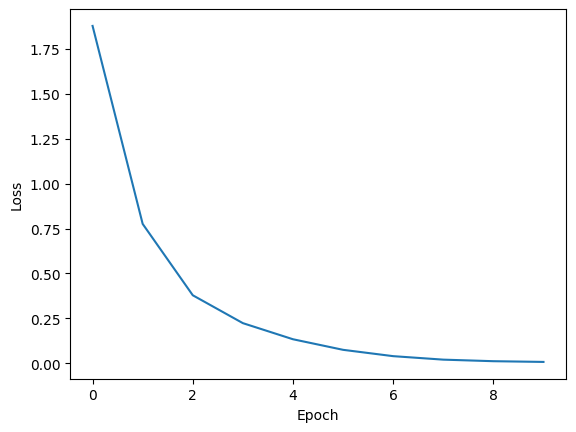

In [16]:
plt.plot(epoch_loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [17]:
# 永続化
for module in model.modules():
  if isinstance(module, torch.nn.Conv2d):
    prune.remove(module, "weight")

In [18]:
# ゼロ比率を表示
for module in model.modules():
  if isinstance(module, torch.nn.Conv2d):
    print(f"{module} Zero-Ratio: {100.0 * float(torch.sum(module.weight == 0)) / float(module.weight.nelement()):.2f}%")

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False) Zero-Ratio: 40.20%
Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False) Zero-Ratio: 47.51%
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False) Zero-Ratio: 68.17%
Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False) Zero-Ratio: 54.78%
Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False) Zero-Ratio: 51.41%
Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False) Zero-Ratio: 56.46%
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False) Zero-Ratio: 63.88%
Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False) Zero-Ratio: 55.66%
Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False) Zero-Ratio: 53.83%
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False) Zero-Ratio: 60.34%
Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False) Zero-Ratio: 60.27%
Conv2d(256, 128, kernel_size=(1, 1), str

In [20]:
model = model.to('cpu')
output = model(input_image.to('cpu'))   #ウォームアップ

start_time = time.time()

with torch.no_grad():
  output = model(input_image)

end_time = time.time()
print(f"推論時間（永続化後）: {end_time - start_time:.4f} 秒")

推論時間（永続化後）: 0.0650 秒


In [23]:
model_to_onnx(model, "resnet50_sparse.onnx")

'resnet50_sparse.onnx'

In [24]:
# SSHした先の計算機がLinuxならつかえるはず。deepsparseはサービス終了しててLinuxでしかつかえないらしい。
!pip install deepsparse==1.8.0

In [25]:
from deepsparse.benchmark.benchmark_model import benchmark_model

def pretty_benchmark(model_path, batch_size):
    result = benchmark_model(model_path, batch_size=batch_size)
    stats = result["benchmark_result"]

    print(f"モデル: {model_path}")
    print(f"バッチサイズ: {batch_size}")
    print(f"推論速度: {stats['items_per_sec']:.2f} items/sec")
    print(f"推論レイテンシ中央値: {stats['median']:.2f} ms")
    print(f"レイテンシ平均: {stats['mean']:.2f} ms")
    print(f"レイテンシ標準偏差: {stats['std']:.2f} ms")
    print(f"実行回数: {stats['iterations']} 回")


/home/rkaneko/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
pretty_benchmark("resnet50_dense.onnx", batch_size=32)
pretty_benchmark("resnet50_sparse.onnx", batch_size=32)

2025-06-16 16:37:01 deepsparse.benchmark.helpers INFO     Thread pinning to cores enabled
DeepSparse, Copyright 2021-present / Neuralmagic, Inc. version: 1.8.0 COMMUNITY | (e3778e93) (release) (optimized) (system=avx512_vnni, binary=avx512)
2025-06-16 16:37:04 deepsparse.benchmark.benchmark_model INFO     deepsparse.engine.Engine:
	onnx_file_path: resnet50_dense.onnx
	batch_size: 32
	num_cores: 20
	num_streams: 1
	scheduler: Scheduler.default
	fraction_of_supported_ops: 1.0
	cpu_avx_type: avx512
	cpu_vnni: True
2025-06-16 16:37:04 deepsparse.utils.onnx INFO     Generating input 'input', type = float32, shape = [32, 3, 224, 224]
2025-06-16 16:37:04 deepsparse.benchmark.benchmark_model INFO     Starting 'singlestream' performance measurements for 10 seconds
2025-06-16 16:37:16 deepsparse.benchmark.helpers INFO     Thread pinning to cores enabled


モデル: resnet50_dense.onnx
バッチサイズ: 32
推論速度: 160.84 items/sec
推論レイテンシ中央値: 198.81 ms
レイテンシ平均: 198.92 ms
レイテンシ標準偏差: 0.48 ms
実行回数: 51 回


2025-06-16 16:37:22 deepsparse.benchmark.benchmark_model INFO     deepsparse.engine.Engine:
	onnx_file_path: resnet50_sparse.onnx
	batch_size: 32
	num_cores: 20
	num_streams: 1
	scheduler: Scheduler.default
	fraction_of_supported_ops: 1.0
	cpu_avx_type: avx512
	cpu_vnni: True
2025-06-16 16:37:22 deepsparse.utils.onnx INFO     Generating input 'input', type = float32, shape = [32, 3, 224, 224]
2025-06-16 16:37:22 deepsparse.benchmark.benchmark_model INFO     Starting 'singlestream' performance measurements for 10 seconds


モデル: resnet50_sparse.onnx
バッチサイズ: 32
推論速度: 399.54 items/sec
推論レイテンシ中央値: 80.01 ms
レイテンシ平均: 80.07 ms
レイテンシ標準偏差: 0.29 ms
実行回数: 125 回


In [28]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 31.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 39.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [35]:
from deepsparse import compile_model
from sklearn.metrics import confusion_matrix

def accuracy(model_name, batch_size):
  model = compile_model(model_name, batch_size=batch_size)
  # model = model.to("cpu") # DeepSparse Engineオブジェクトには.to()メソッドはありません。CPUで実行されます

  with torch.no_grad():
    all_labels = []
    all_predictions = []

    for i, (inputs, labels) in enumerate(testloader):
      if i>=312:
        break
     
      inputs = inputs.to("cpu")
      labels = labels.to("cpu")

      outputs = model([inputs.numpy()])
      outputs = torch.from_numpy(outputs[0])

      predicted = torch.max(outputs, 1)[1]

      all_labels.extend(labels)
      all_predictions.extend(predicted)

  all_labels = np.array(all_labels)
  all_predictions = np.array(all_predictions)
  cm = confusion_matrix(all_labels, all_predictions)
  accuracy = np.sum(np.diag(cm)) / np.sum(cm)
  print(f"正解率: {accuracy:.4f}")

In [36]:
accuracy("resnet50_dense.onnx", batch_size=32)
accuracy("resnet50_sparse.onnx", batch_size=32)

正解率: 0.0756
正解率: 0.8307


In [ ]:
# 本当はdeepsparse使いたかったけど、Colabではつかえなかった。onnxruntimeはおそらく疎計算に対応していないから、denseとsparseで速度に違いが見られない。
import onnxruntime as ort
import numpy as np

# モデルパス
model_paths = ["resnet50_dense.onnx", "resnet50_sparse.onnx"]

# 入力サイズ（例: 1枚のカラー画像、224x224）
input_shape = (1, 3, 224, 224)
input_data = np.random.randn(*input_shape).astype(np.float32)

# 推論回数（平均を取るため）
num_runs = 50

# 比較ループ
for model_path in model_paths:
    # モデル読み込み
    session = ort.InferenceSession(model_path)
    input_name = session.get_inputs()[0].name

    # ウォームアップ（初回は遅くなるため）
    session.run(None, {input_name: input_data})

    # 時間計測
    start = time.time()
    for _ in range(num_runs):
        outputs = session.run(None, {input_name: input_data})
    end = time.time()

    avg_time = (end - start) / num_runs  # 秒単位
    print(f"{model_path}: 平均推論時間 = {avg_time:.4f} 秒（{num_runs}回平均）")


resnet50_dense.onnx: 平均推論時間 = 0.1557 秒（50回平均）
resnet50_sparse.onnx: 平均推論時間 = 0.1389 秒（50回平均）


In [ ]:
def benchmark(model_path, input_shape=(1, 3, 224, 224), num_images=100):
    session = ort.InferenceSession(model_path)
    input_name = session.get_inputs()[0].name

    # ランダムな入力データを生成
    inputs = [np.random.randn(*input_shape).astype(np.float32) for _ in range(num_images)]

    # ウォームアップ（最初の遅延回避）
    session.run(None, {input_name: inputs[0]})

    # 推論時間を測定
    total_time = 0.0
    for inp in inputs:
        start = time.time()
        session.run(None, {input_name: inp})
        end = time.time()
        total_time += (end - start)

    avg_time = total_time / num_images
    print(f"{model_path}: 平均推論時間 {avg_time:.6f} 秒（{num_images}枚）")

# 使用例
benchmark("resnet50_dense.onnx")
benchmark("resnet50_sparse.onnx")


resnet50_dense.onnx: 平均推論時間 0.144067 秒（100枚）
resnet50_sparse.onnx: 平均推論時間 0.143795 秒（100枚）
